In [2]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from config_mounir import NearOODFramework
from eval_functions import train, auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite, performance_report
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Préparation des données

(Passage à **3 modalités**, **Near OOD**)

Le but ici est de passer à 3 modalités. Comme Kinetics n'est pas disponible et que HMDB n'a pas l'audio, on est obligé de faire du Near OOD. Et comme il n'a pas été procuré de modèle entraîné sur HAC en Near OOD, on est obligé de faire les expériences sur EPIC.

Même principe que far ood mais on a une dimension en plus (React(audio))

On charge les fichiers conf sur EPIC en Near OOD, mais provenant de différents splits. Le split "test" (de même que "train" qu'on utilisera pas) contient les classes 0 à 3 pour l'ID, et le split "eval" contient les classes de 4 à 7 pour l'OOD. 

In [28]:
root_dir = "/data/maouche/MultiOOD/HMDB-rgb-flow/saved_files/"
datasets = ['HMDB', 'UCF', 'EPIC']
modalities = ['video', 'flow'] #

## Création des datasets

Les scores de confiance qu'on va utiliser ont été générés via des modèles différents, chaque modèle entraîné sur un des 3 datasets, ce qui fait que leurs scores ne sont pas forcément comparables. On doit donc entraîner un modèle sur chaque dataset séparément.

Données ID

In [5]:
template_sans_react =  "id_{}_near_ood_conf_baseline_best_test.npy"
template_react_tout = "id_{}_near_ood_conf_baseline_best_react_test.npy"
template_par_modalite = "id_{}_near_ood_conf_baseline_best_react_{}_test.npy"

datasets_id = {}

for dataset in datasets:

    # Sans react
    conf_sans_react = np.load(root_dir+template_sans_react.format(dataset))
    conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

    # React sur tout
    conf_react_tout = np.load(root_dir+template_react_tout.format(dataset))
    conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


    # React par modalité
    conf_une_modalite = []
    for modality in modalities:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.hstack(conf_une_modalite)

    dataset_id = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,5)
    datasets_id[dataset] = dataset_id

Données OOD

In [6]:
template_sans_react =  "id_{}_near_ood_conf_baseline_best_eval.npy"
template_react_tout = "id_{}_near_ood_conf_baseline_best_react_eval.npy"
template_par_modalite = "id_{}_near_ood_conf_baseline_best_react_{}_eval.npy"

datasets_ood = {}
for dataset in datasets:
    # Sans react
    conf_sans_react = np.load(root_dir+template_sans_react.format(dataset))
    conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

    # React sur tout
    conf_react_tout = np.load(root_dir+template_react_tout.format(dataset))
    conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


    # React par modalité
    conf_une_modalite = []
    for modality in modalities:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.hstack(conf_une_modalite)

    dataset_ood = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,4)
    datasets_ood[dataset] = dataset_ood

In [7]:
X = {}
for (name_id, dataset_id), (name_ood, dataset_ood) in list(zip(datasets_id.items(), datasets_ood.items())):
    X[name_id] = np.vstack([dataset_id, dataset_ood])
    
#X = np.vstack([dataset_id, dataset_ood])

In [8]:
len(X["HMDB"]), len(X["UCF"]), len(X["EPIC"])

(4203, 7646, 1856)

Création des labels

In [9]:
# inutile mais bon pour visualisation
template_label_id =  "id_EPIC_near_ood_label_baseline_best_test.npy"
labels_id = np.load(root_dir+template_label_id)

template_label_ood =  "id_EPIC_near_ood_label_baseline_best_eval.npy"
labels_ood = np.load(root_dir+template_label_ood)
print(np.unique(labels_id, return_counts=True), len(labels_id))
print(np.unique(labels_ood, return_counts=True), len(labels_ood))


(array([0, 1, 2, 3]), array([174, 211,  84,  67])) 536
(array([4, 5, 6, 7]), array([1053,  139,   54,   74])) 1320


In [10]:
Y = {}
for dataset in datasets:
    y_id = np.zeros(datasets_id[dataset].shape[0])
    y_id = y_id.reshape(y_id.shape[0], 1)
    y_ood = np.ones(datasets_ood[dataset].shape[0])
    y_ood = y_ood.reshape(y_ood.shape[0], 1)

    Y[dataset] = np.vstack([y_id, y_ood])

In [11]:
for dataset in datasets:
    print(X[dataset].shape, Y[dataset].shape)

(4203, 4) (4203, 1)
(7646, 4) (7646, 1)
(1856, 4) (1856, 1)


## Création des dataloaders

In [ ]:
data = {}
for dataset in datasets:    
    X_train, X_test, y_train, y_test = train_test_split(
                    X[dataset], Y[dataset], stratify=Y[dataset], test_size=0.2, random_state=42)

    data[dataset] = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [14]:
with open("data_near.pkl", 'wb') as f:
    pickle.dump(data, f)

# Chargement

In [5]:
with open("data_near.pkl", 'rb') as f:
    data_all = pickle.load(f)

# Dataset HMDB

## Chargement des données

In [4]:
data = data_all["HMDB"]

In [5]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

3362 elements (array([0., 1.], dtype=float32), array([ 367, 2995]))


In [6]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

841 elements (array([0., 1.], dtype=float32), array([ 92, 749]))


## Modèle 1 Couche

In [7]:
input_dim = 4  #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.12253756260434057

### Entrainement

cuda
accuracy train:  0.6892531315485636


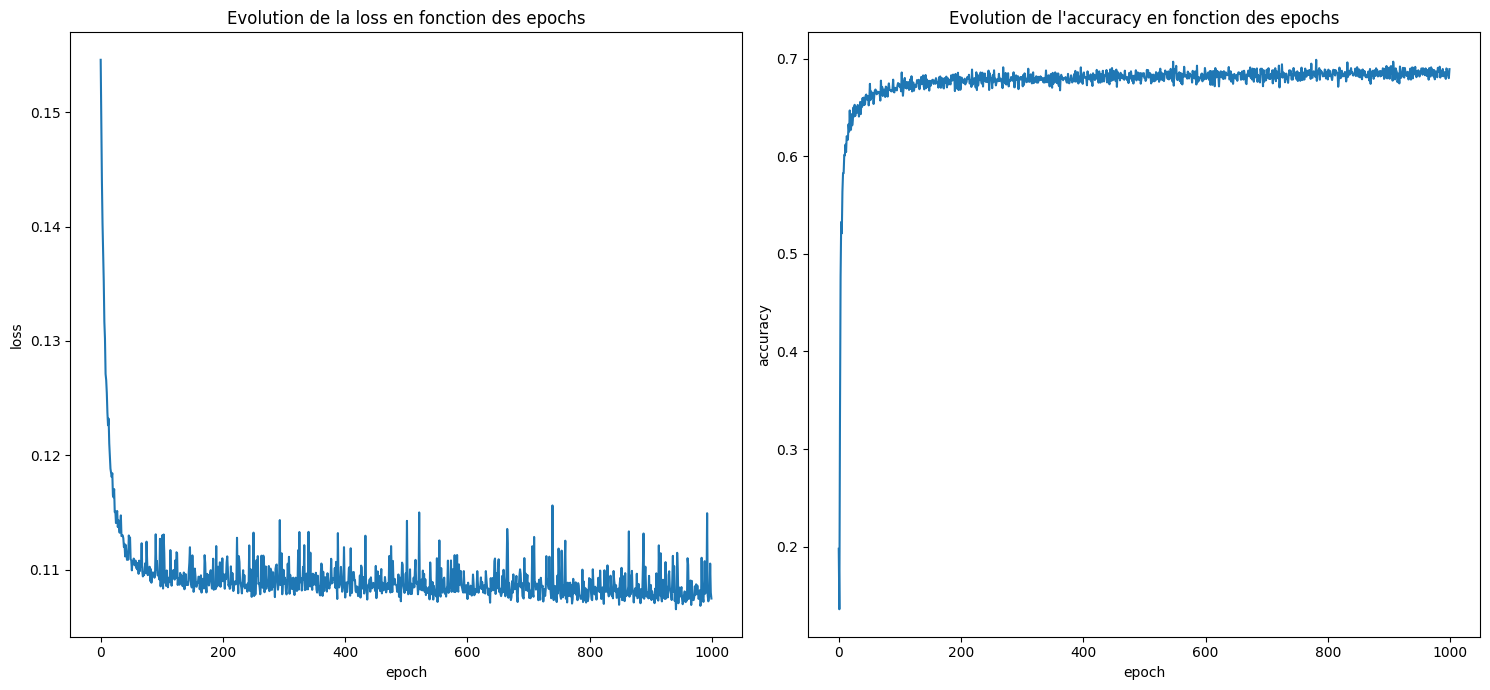

In [14]:
nb_epochs = 1000
lr = 1
model = nn.Linear(input_dim, output_dim)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
#torch.save(model.state_dict(), "model_near_hmdb.pth")

In [8]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_near_hmdb.pth"))

<All keys matched successfully>

In [ ]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[ 1.9167, -5.4552, -5.3488,  1.1961]])
bias
tensor([6.6474])


Accuracy test:  0.8906
Séparabilité:


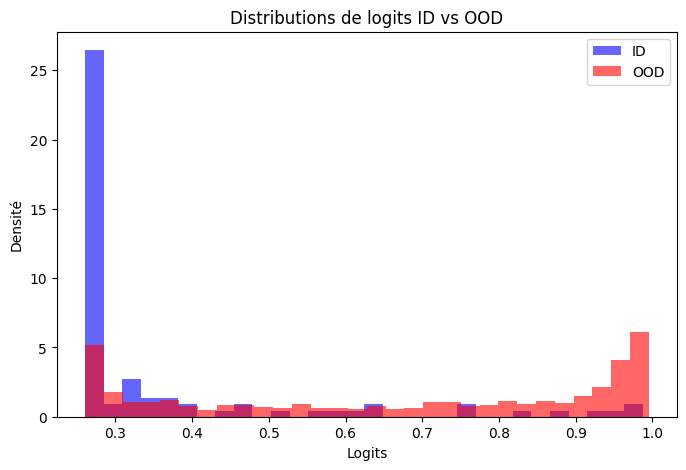

AUC ROC: 0.8499
FPR@TPR95: 0.5217

Correlation ID :  -0.8729230035254288
Correlation OOD :  -0.8607655673494419


,config,tout,video,flow
0,poids_near_ood,-5.4552,-5.3488,1.1961
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [26]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"))

## 2 couches

cuda
accuracy train:  0.6763344230475249


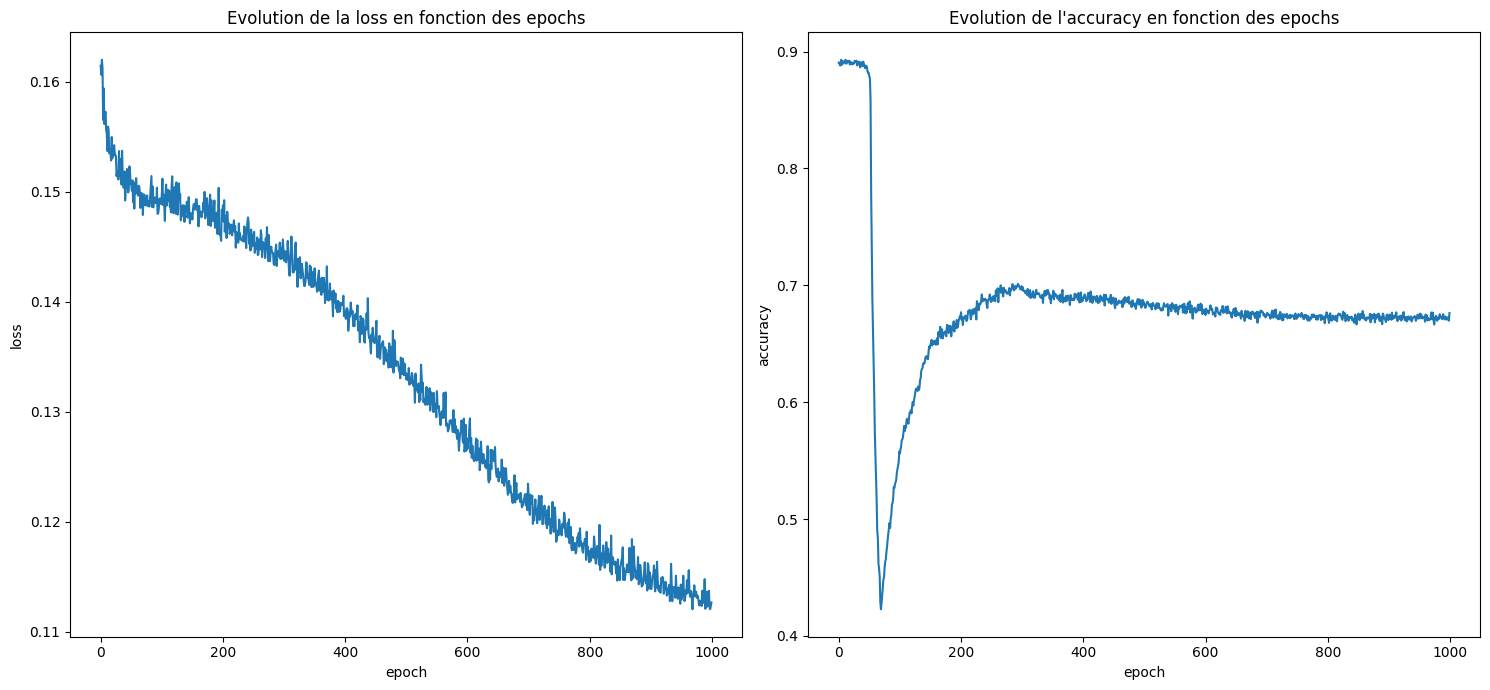

cuda
accuracy train:  0.7614038674919693


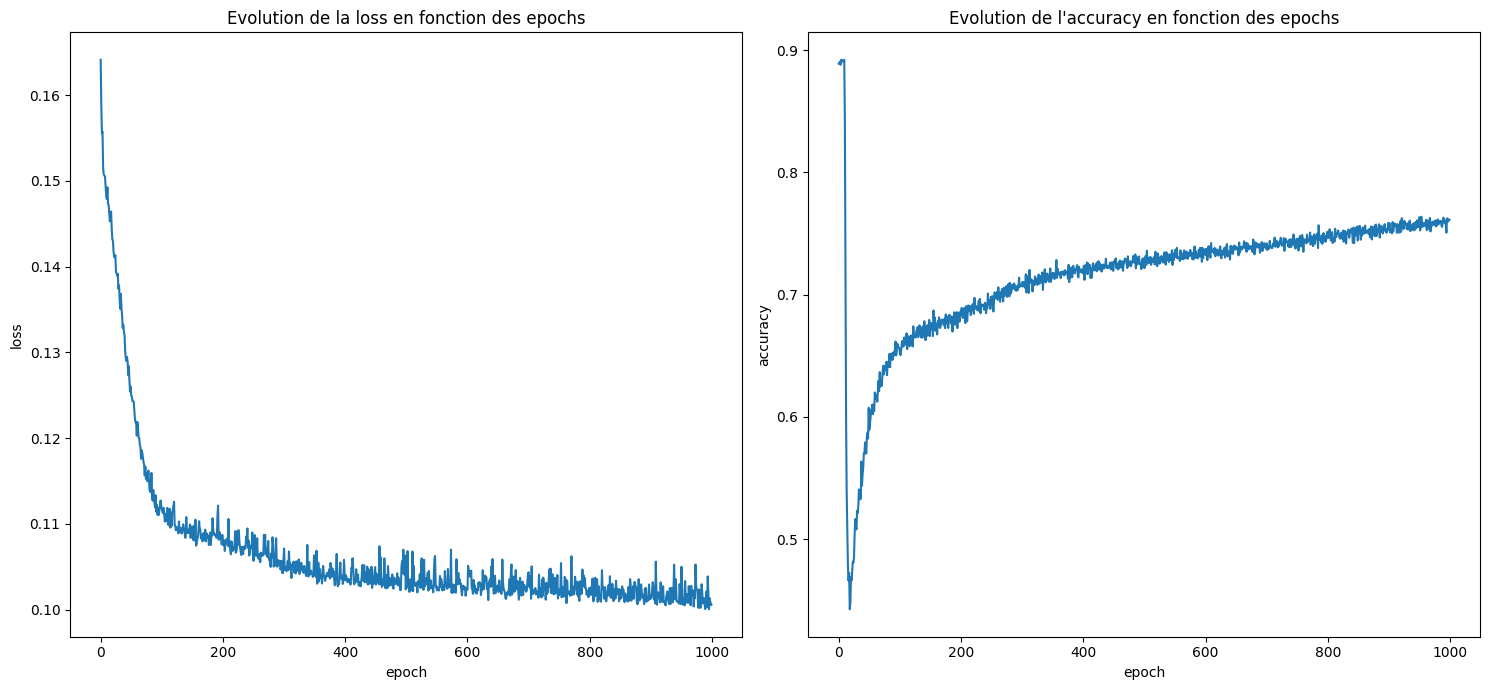

cuda
accuracy train:  0.7732502729804428


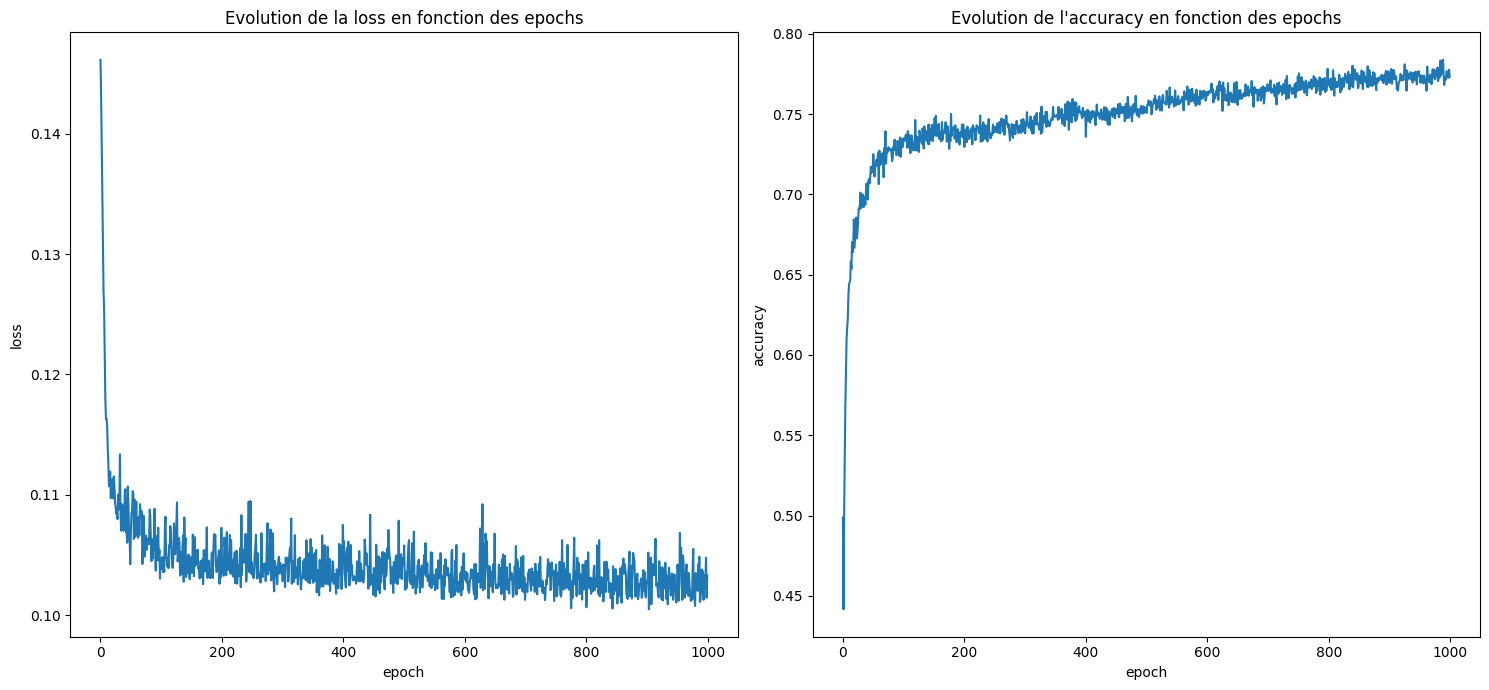

cuda
accuracy train:  0.8079895156401175


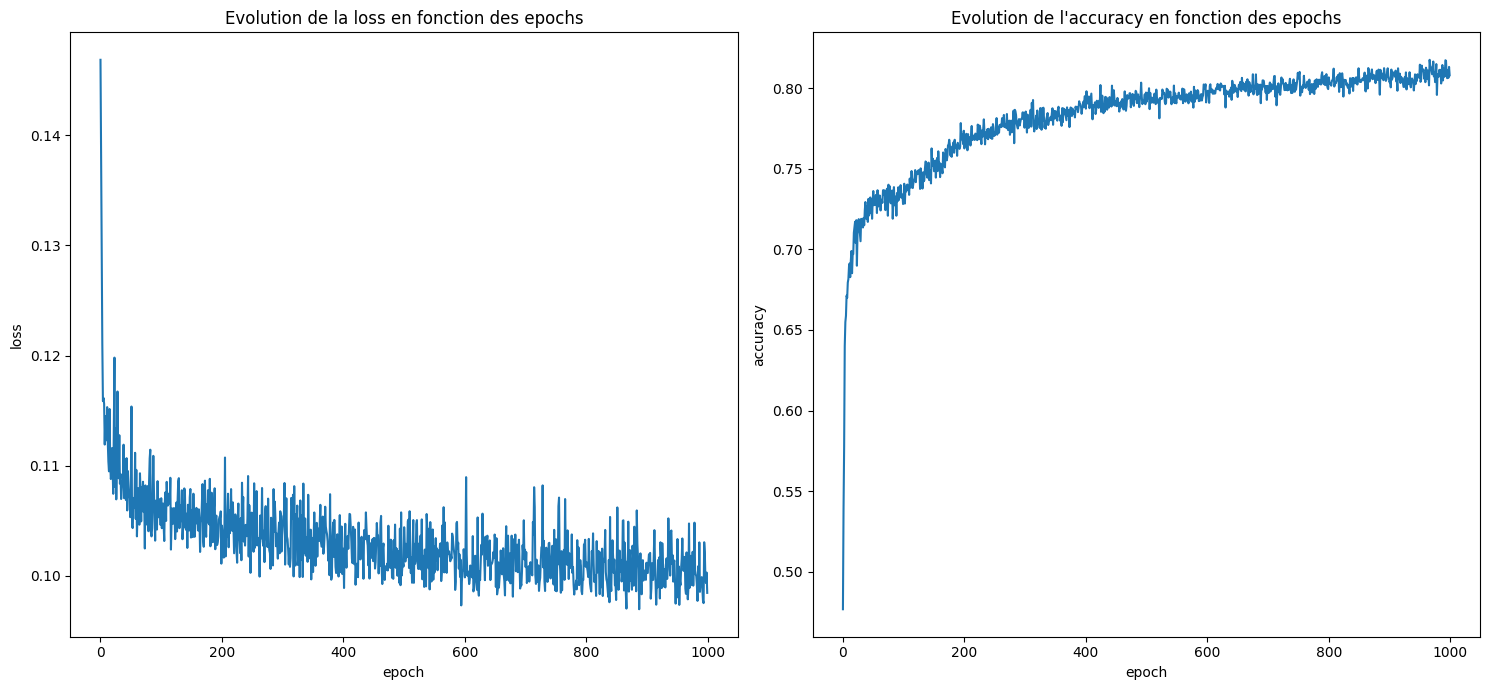

In [12]:
models = {}
nb_epochs = 1000
for lr in [1e-2, 1e-1, 1, 2]:
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [ ]:
model = models[2]
#torch.save(model.state_dict(), "model_near_hmdb_2c.pth")

In [27]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

model.load_state_dict(torch.load("model_near_hmdb_2c.pth"))

<All keys matched successfully>

Accuracy test:  0.8906
Séparabilité:


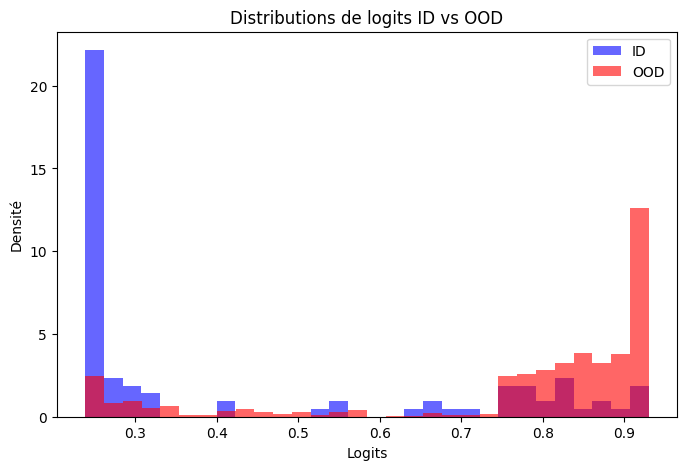

AUC ROC: 0.847
FPR@TPR95: 0.5109



In [28]:
outputs_test, auroc, fpr, *_ = performance_report(model, test_dataloader, NearOODFramework("near_ood"), correlations=False)

# Dataset UCF

## Chargement des données

In [6]:
data = data_all["UCF"]

In [7]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

6116 elements (array([0., 1.], dtype=float32), array([ 824, 5292]))


In [8]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

1530 elements (array([0., 1.], dtype=float32), array([ 206, 1324]))


## Modèle 1 Couche

In [ ]:
input_dim = 4  #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.15570672713529857

## Entrainement

cuda
accuracy train:  0.652285156150659


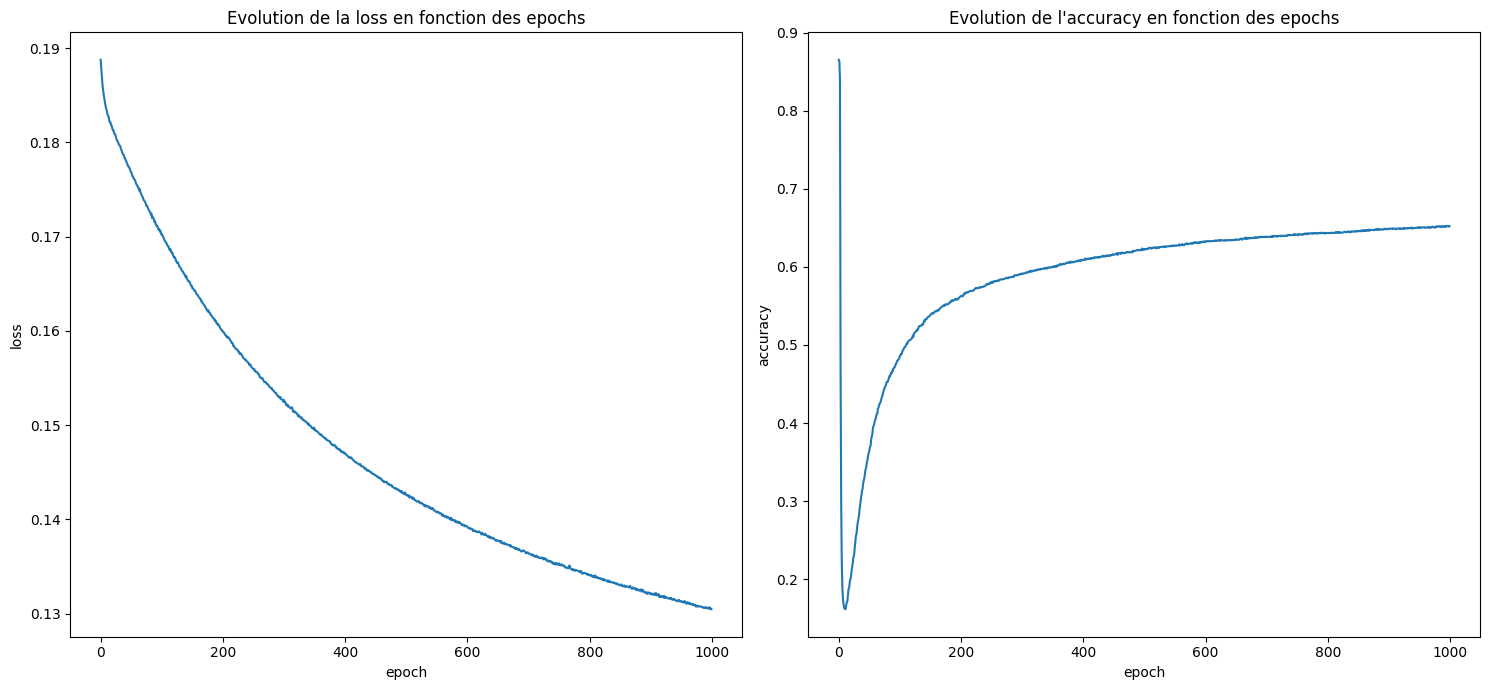

cuda
accuracy train:  0.7138671875


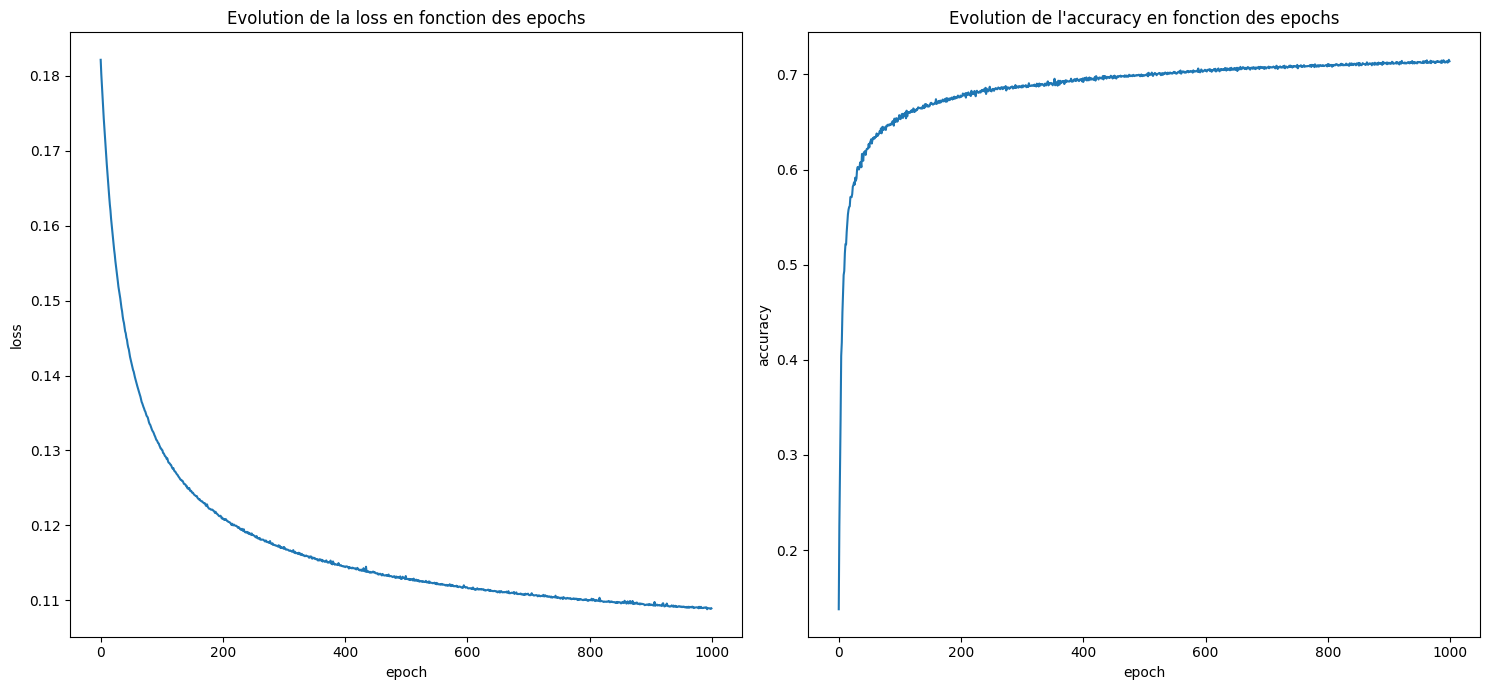

cuda
accuracy train:  0.7499283850193024


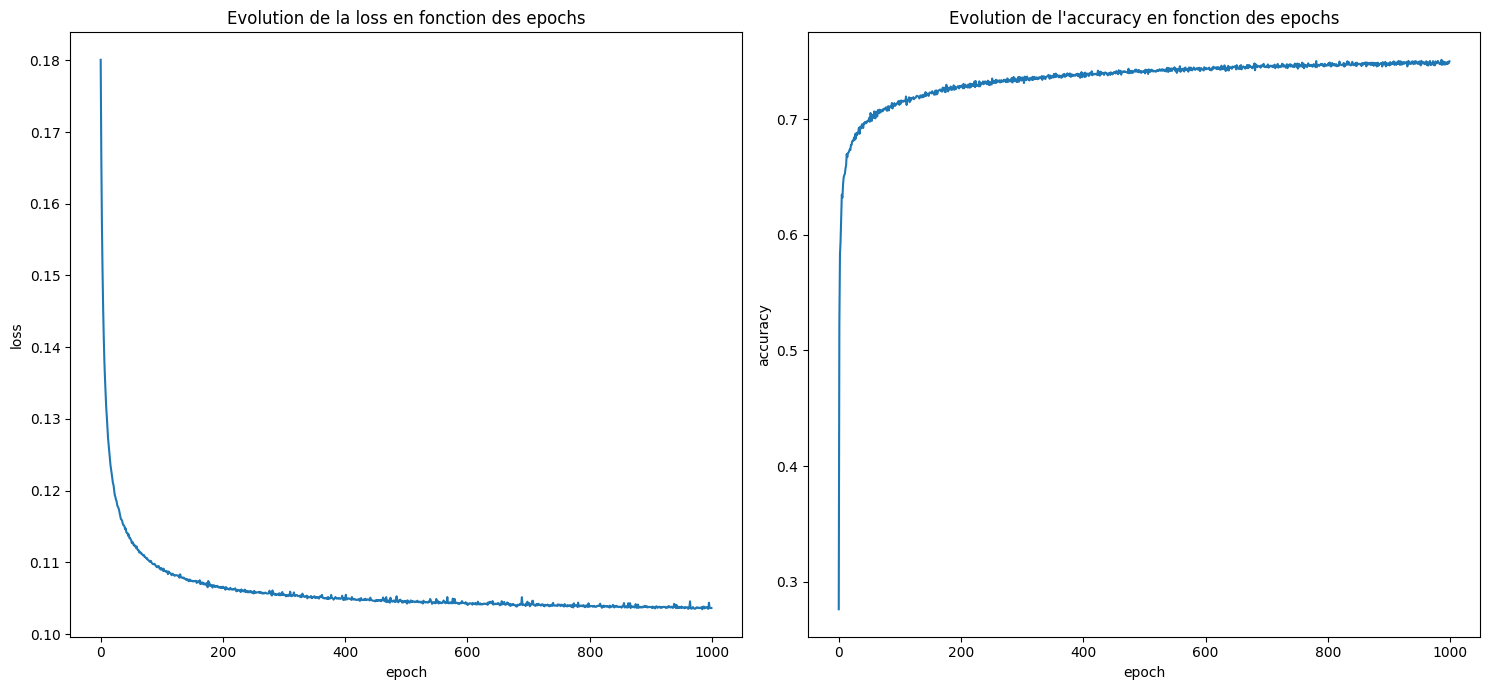

cuda
accuracy train:  0.7540234376986822


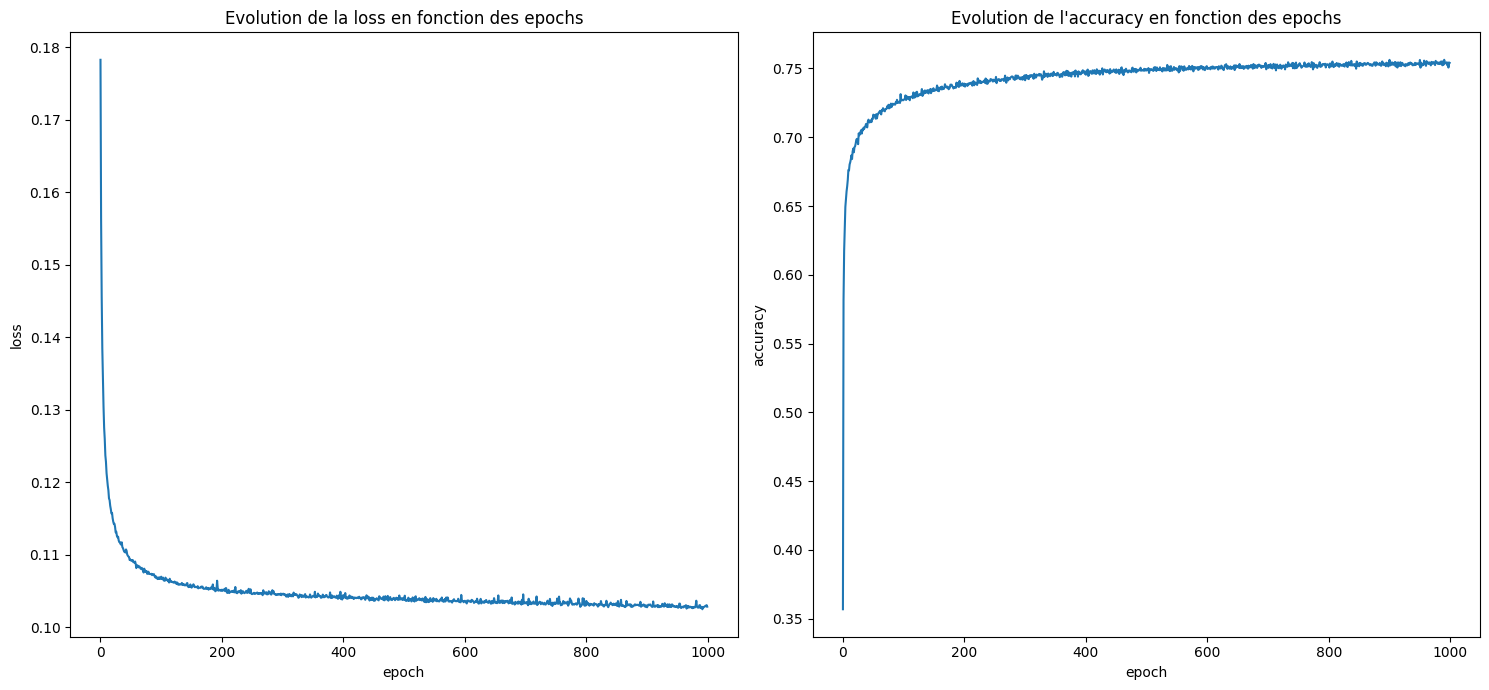

In [21]:
models = {}
nb_epochs = 1000
for lr in [1e-2, 1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [9]:
#torch.save(model.state_dict(), "model_near_ucf.pth")

input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_near_ucf.pth"))

<All keys matched successfully>

In [ ]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[  5.6292, -16.2795, -10.8432,   0.2980]])
bias
tensor([19.8186])


Accuracy test:  0.8654
Séparabilité:


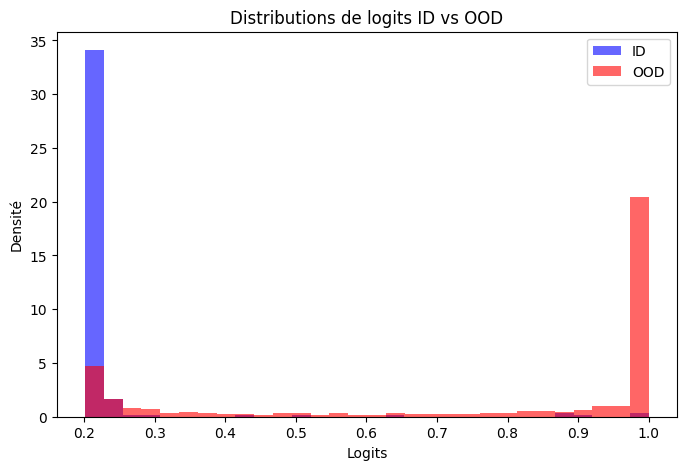

AUC ROC: 0.9491
FPR@TPR95: 0.2427

Correlation ID :  -0.9808276483144069
Correlation OOD :  -0.9757832882374313


,config,tout,video,flow
0,poids_near_ood,-16.279499,-10.8432,0.2980
1,perturbation_near_ood_id,0.005200,0.0035,0.0018
2,perturbation_near_ood_ood,0.021100,0.0137,0.0069


In [10]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"))

## 2 couches

cuda
accuracy train:  0.7224023429056009


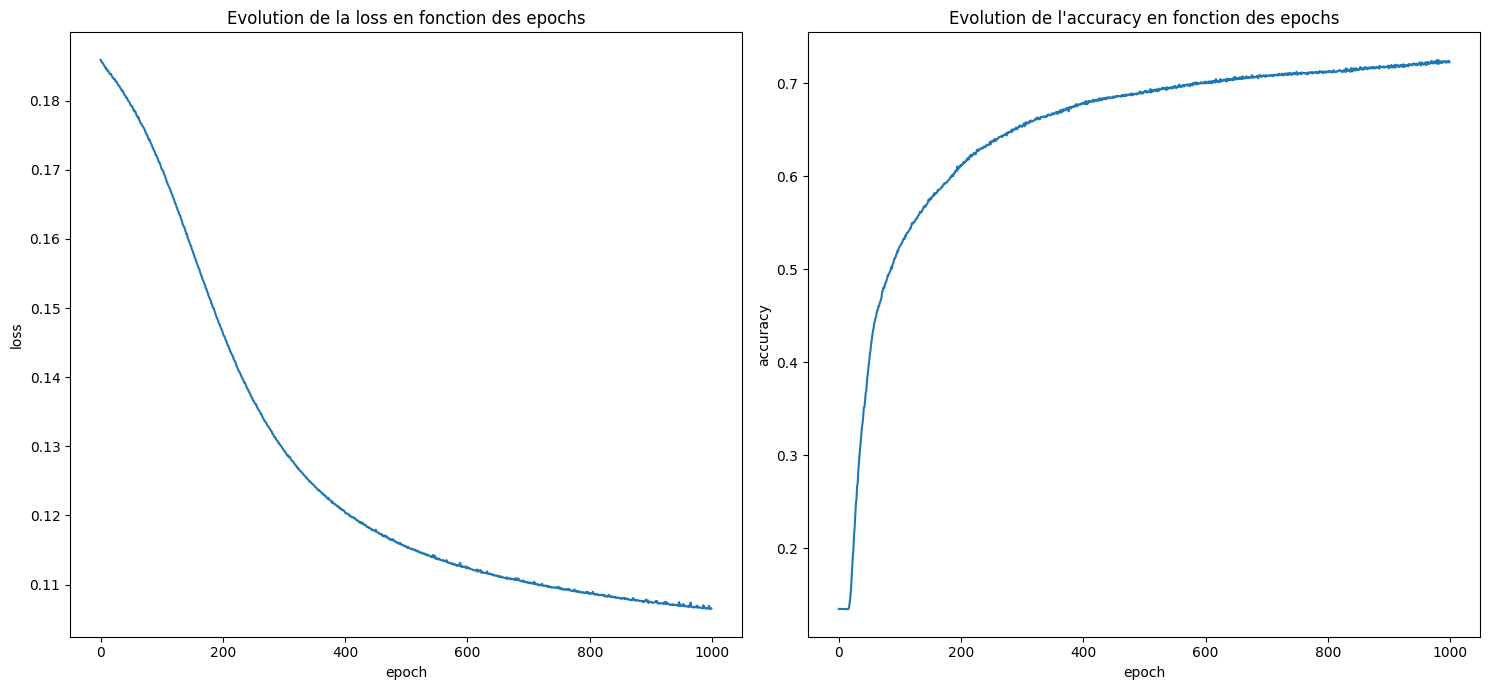

cuda
accuracy train:  0.4883398438493411


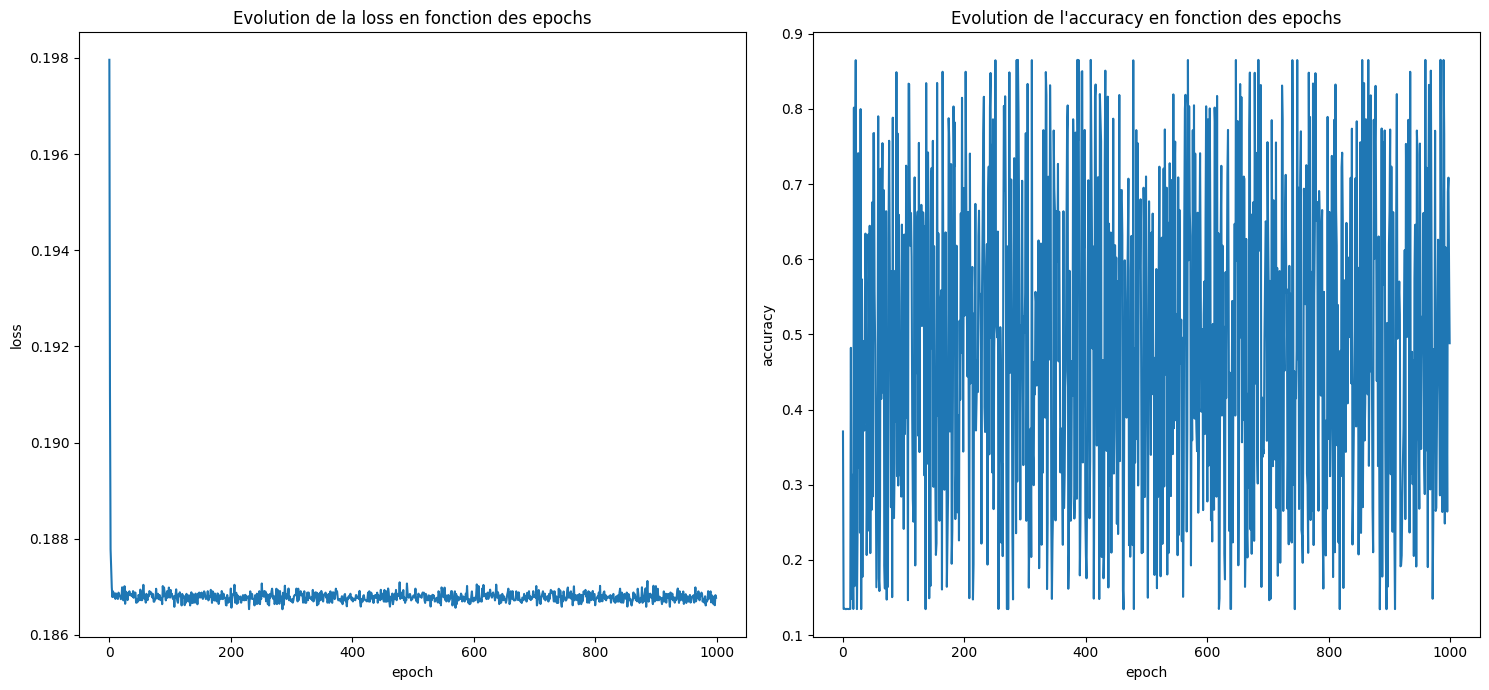

cuda
accuracy train:  0.8242838531732559


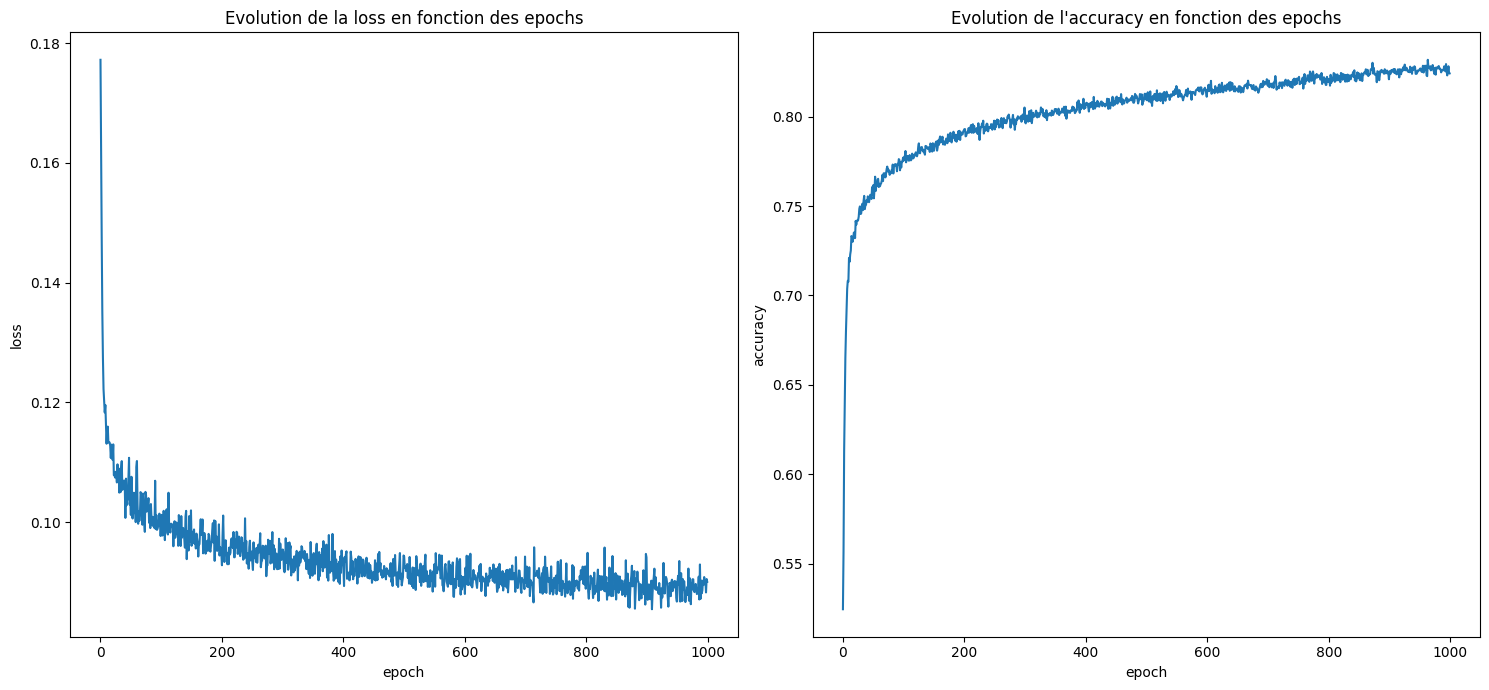

cuda
accuracy train:  0.607317708277454


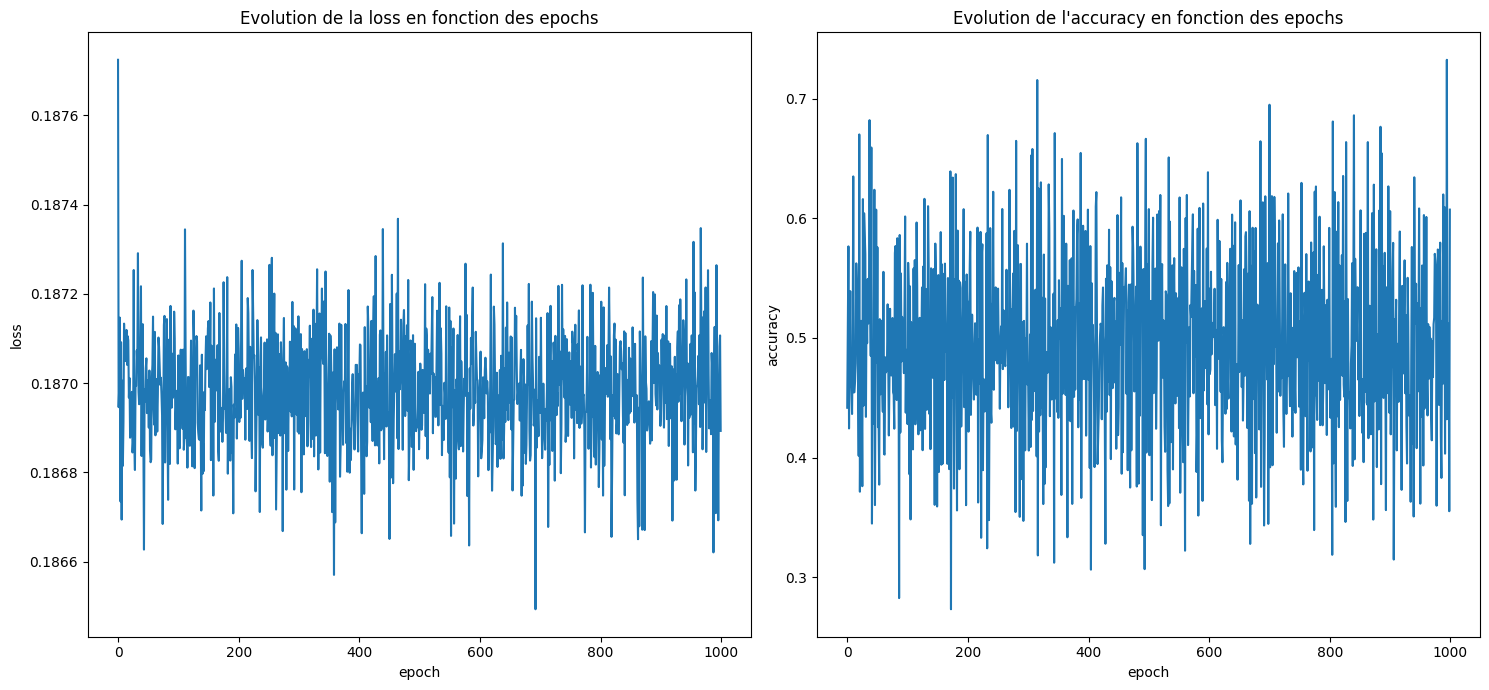

In [34]:
models = {}
nb_epochs = 1000
for lr in [1e-2, 1e-1, 1, 2]:
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [35]:
# model = models[1]
# torch.save(model.state_dict(), "model_near_ucf_2c.pth")

input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

model.load_state_dict(torch.load("model_near_ucf_2c.pth"))

<All keys matched successfully>

Accuracy test:  0.8654
Séparabilité:


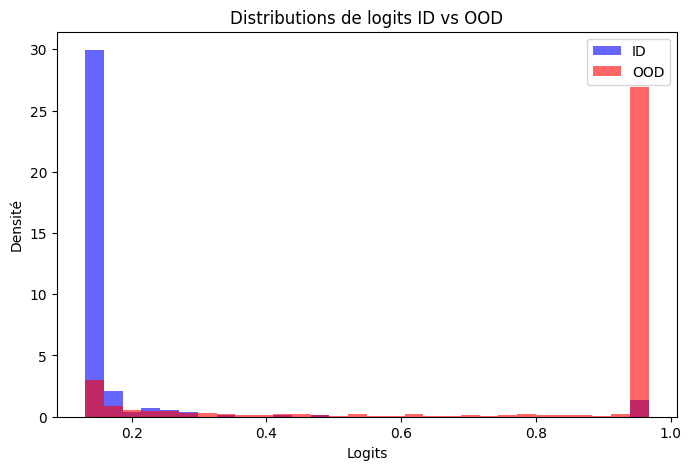

AUC ROC: 0.9437
FPR@TPR95: 0.2427



In [37]:
outputs_test, auroc, fpr, *_ = performance_report(model, test_dataloader, NearOODFramework("near_ood"), correlations=False)

# Dataset EPIC

## Chargement des données

In [38]:
data = data_all["EPIC"]

In [39]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


In [40]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([107, 265]))


## Modèle 1 Couche

In [7]:
input_dim = 4  #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1

# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.4066350710900474

In [ ]:
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.2
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 500

## Entrainement

cuda
accuracy train:  0.5456560292142503


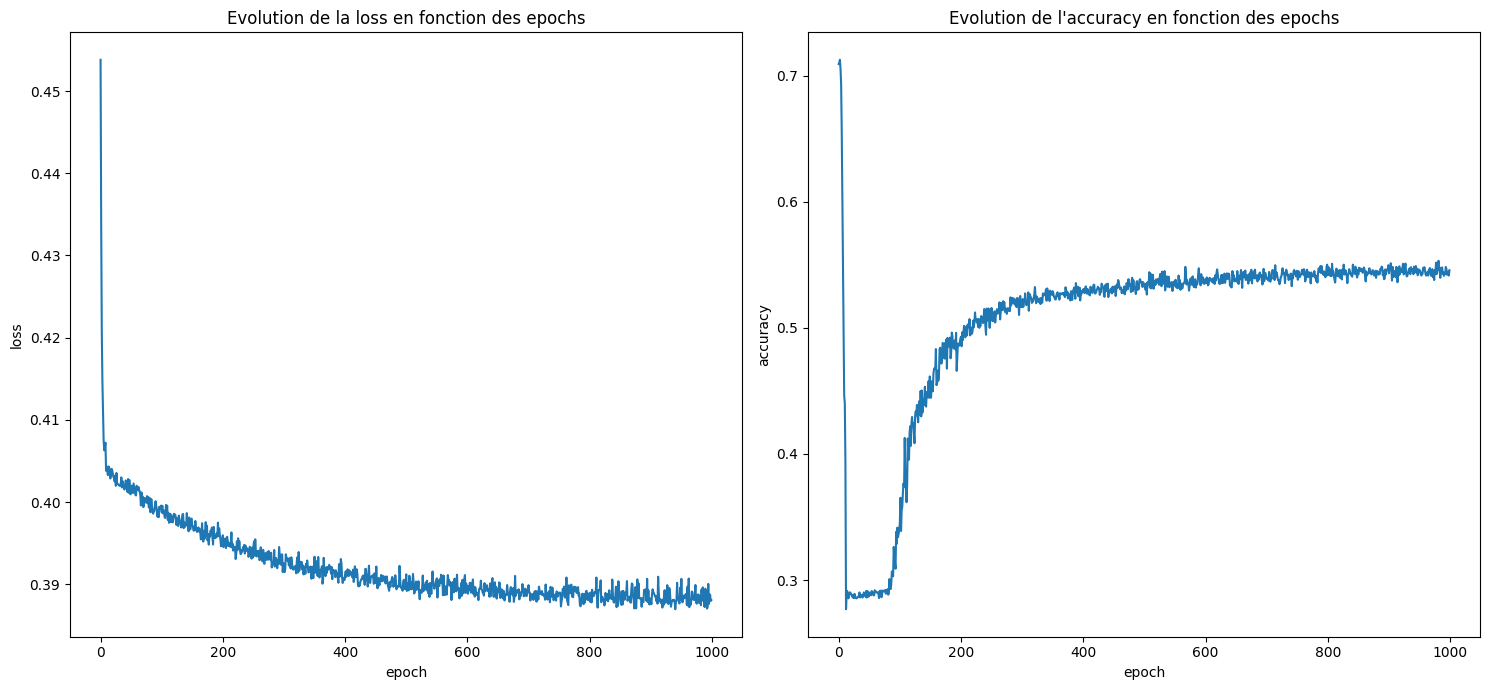

cuda
accuracy train:  0.5662677313419099


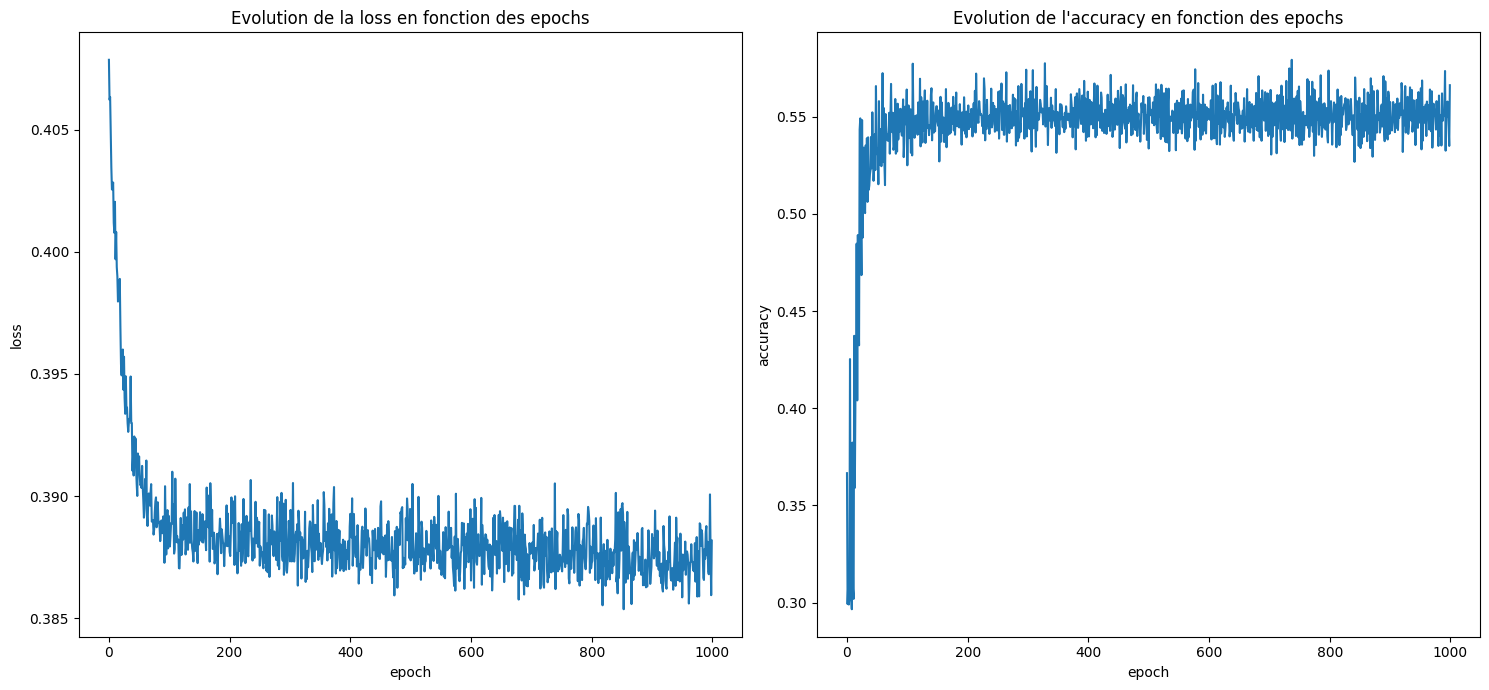

cuda
accuracy train:  0.563386525245423


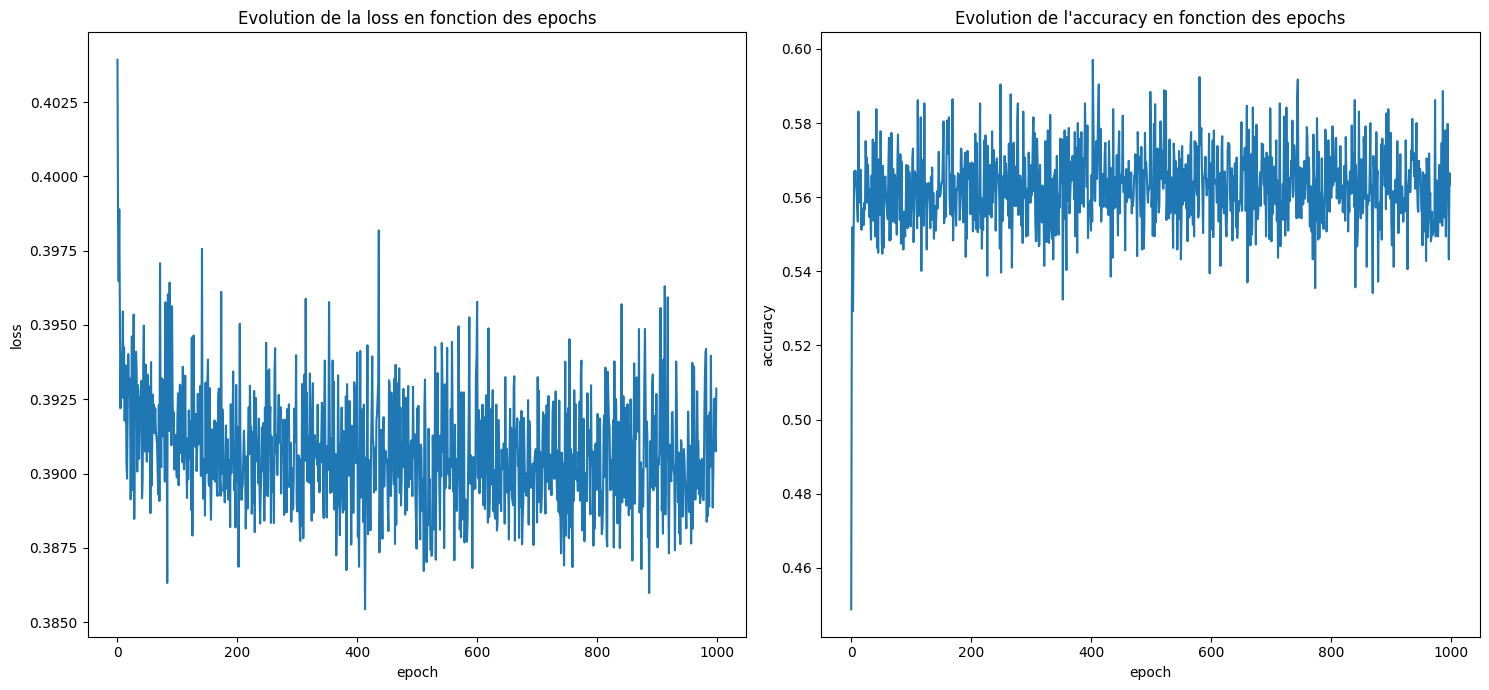

cuda
accuracy train:  0.5720301419496536


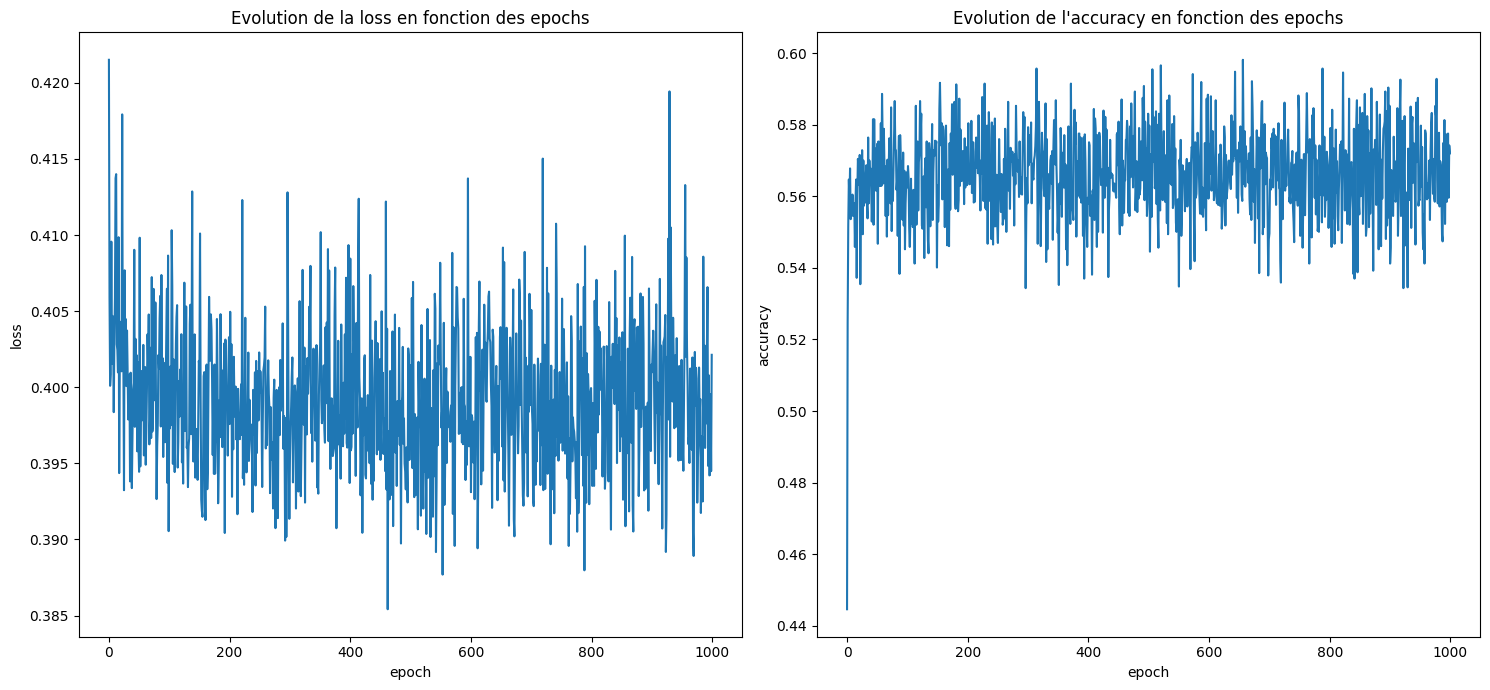

In [8]:
models = {}
nb_epochs = 1000
for lr in [1e-2, 1e-1, 1, 2]:
    model = nn.Linear(input_dim, output_dim)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [41]:
#model = models[1e-1]
#torch.save(model.state_dict(), "model_near_epic.pth")

input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

model.load_state_dict(torch.load("model_near_epic.pth"))

<All keys matched successfully>

In [10]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-1.9404,  0.6576, -1.8700,  0.6977]], device='cuda:0')
bias
tensor([2.0331], device='cuda:0')


Accuracy test:  0.7124
Séparabilité:


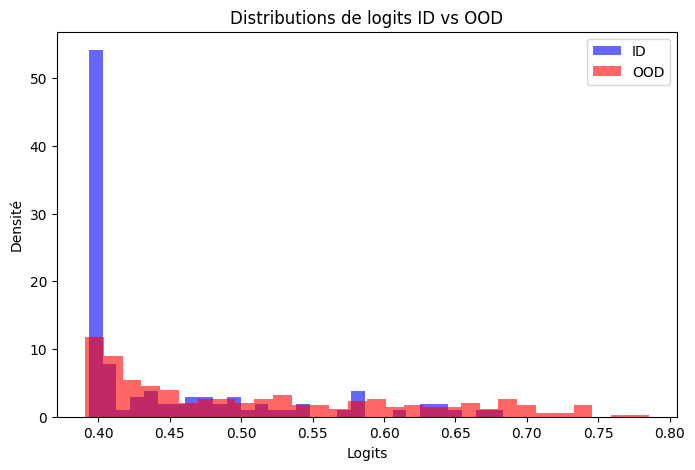

AUC ROC: 0.7256
FPR@TPR95: 0.6916

Correlation ID :  -0.013630022292829778
Correlation OOD :  0.010759609904089883


,config,tout,video,flow
0,poids_near_ood,0.6576,-1.8700,0.6977
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0211,0.0137,0.0069


In [42]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, NearOODFramework("near_ood"))

Accuracy test:  0.7124
Séparabilité:


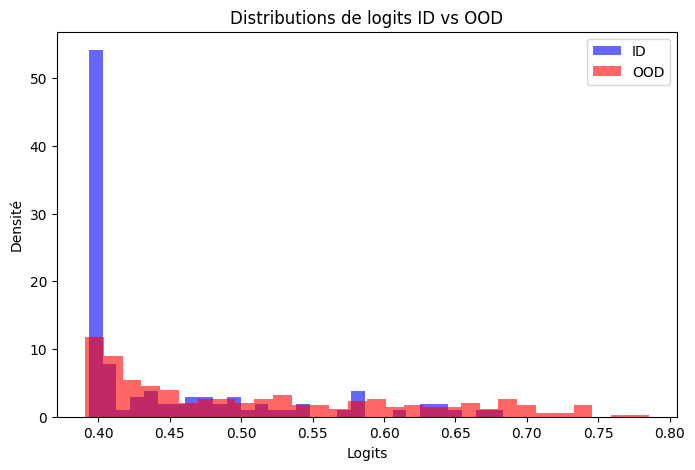

AUC ROC: 0.7256
FPR@TPR95: 0.6916

Correlation ID :  -0.08556951979420031
Correlation OOD :  0.33983986522946524


,config,tout,video,flow
0,poids_far_ood,0.6576,-1.8700,0.6977
1,perturbation_far_ood_id,0.0089,0.0061,0.0025
2,perturbation_far_ood_ood,0.0299,0.0161,0.0132


In [11]:
# erroné
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader, mode="1c")

## 2 couches

cuda
accuracy train:  0.5926418443943592


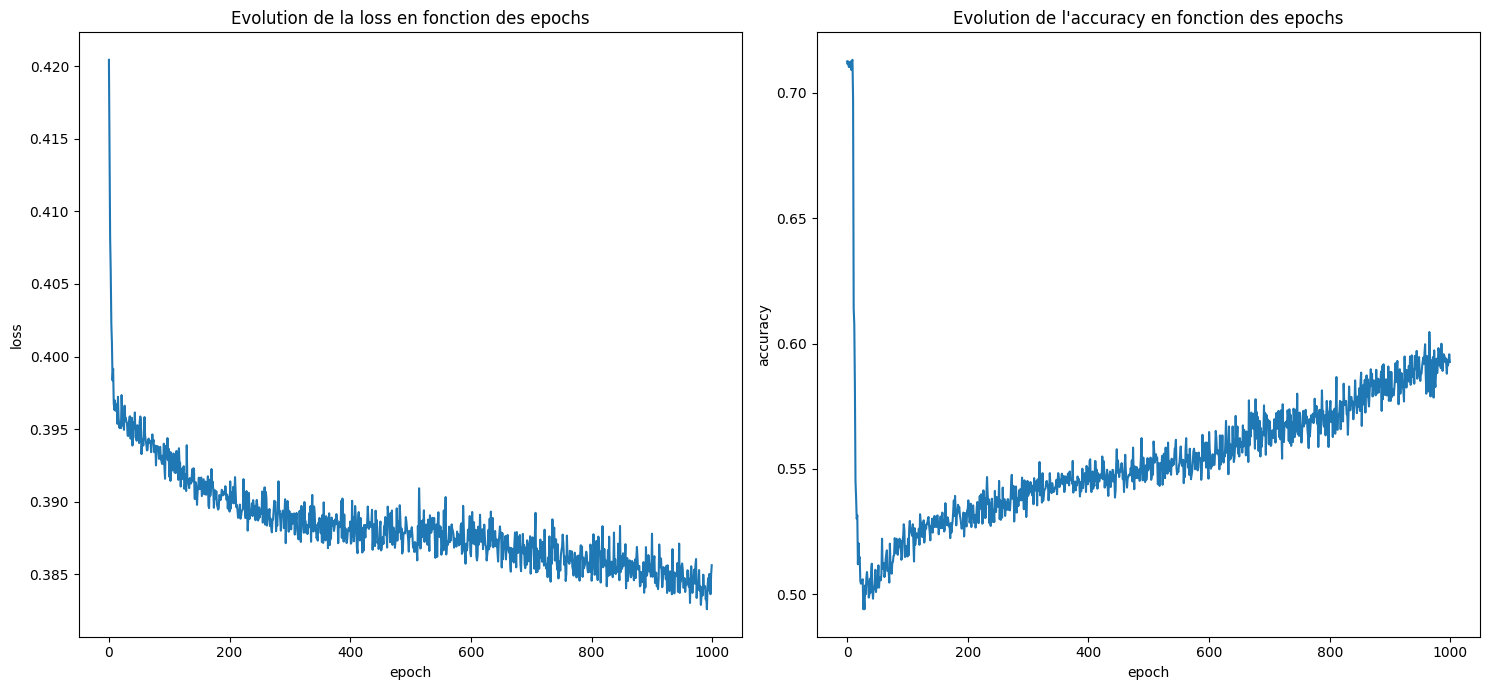

cuda
accuracy train:  0.6363031914893617


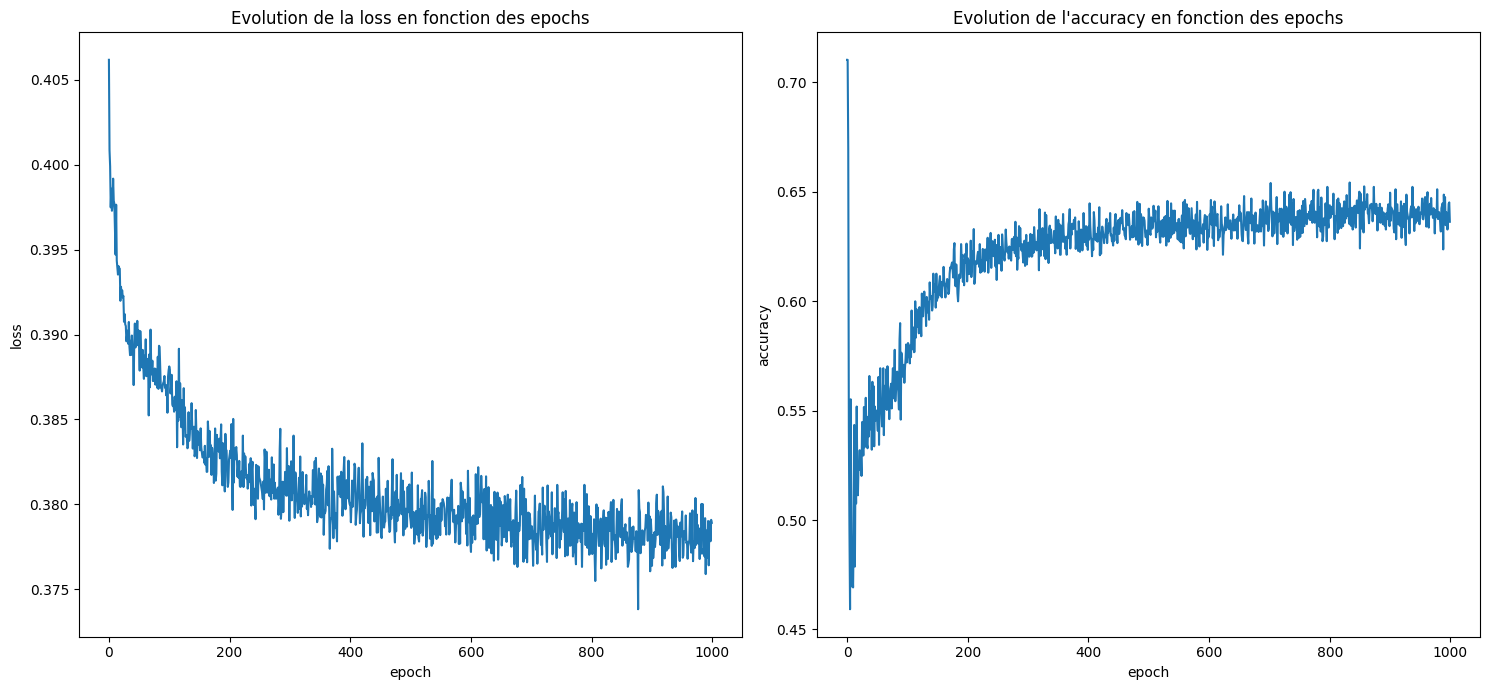

cuda
accuracy train:  0.636968085106383


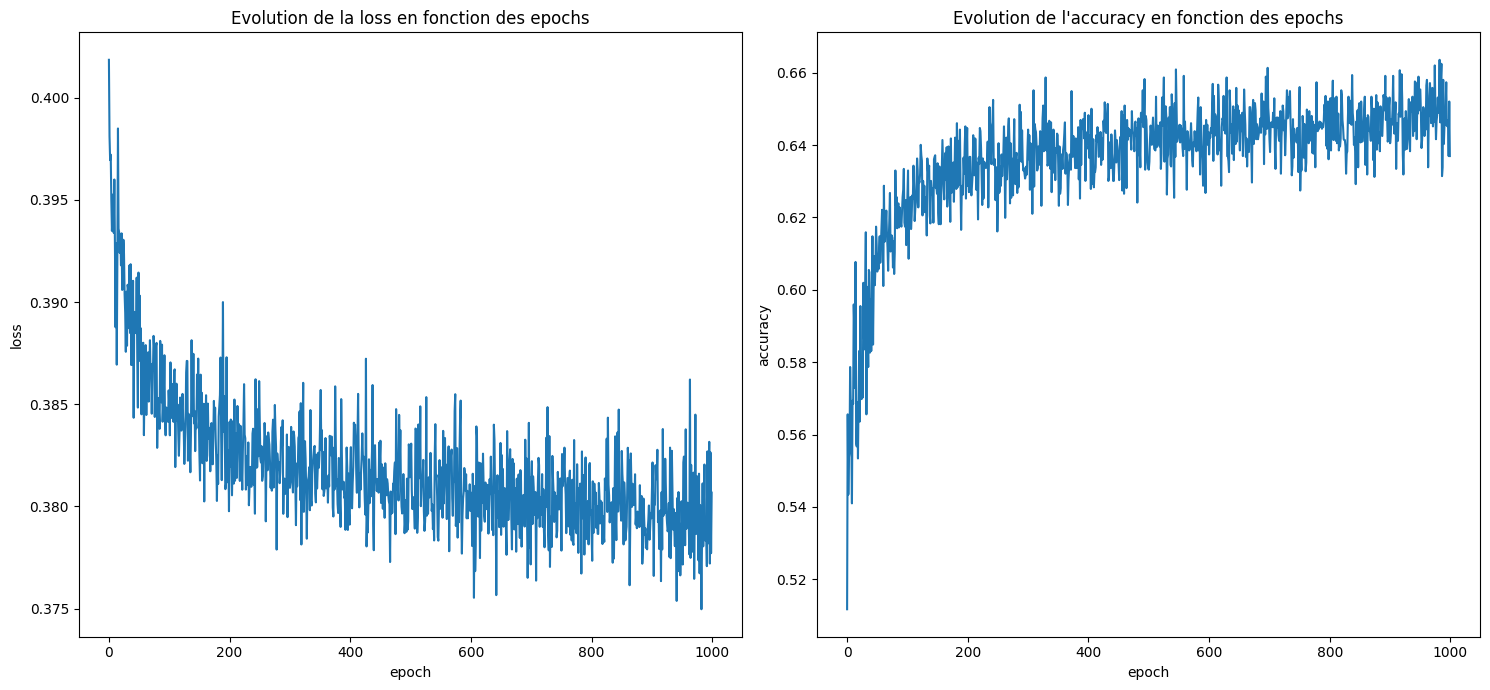

cuda
accuracy train:  0.5232712765957447


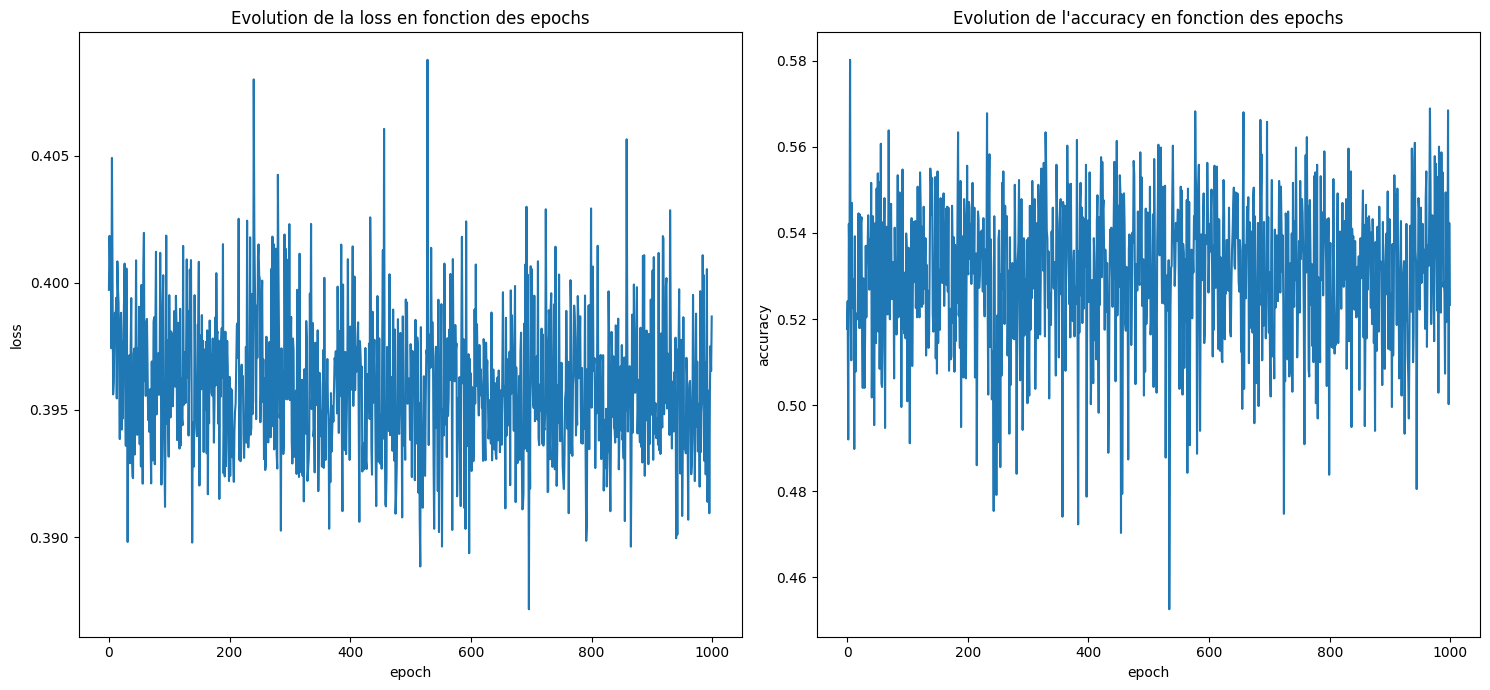

In [12]:
models = {}
nb_epochs = 1000
for lr in [1e-2, 1e-1, 1, 2]:
    model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
    optim = torch.optim.SGD(model.parameters(), lr)
    plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
    visualize(plot_loss, plot_acc)
    models[lr] = model

In [43]:
#model = models[1e-1]
#torch.save(model.state_dict(), "model_near_epic_2c.pth")

input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
model.load_state_dict(torch.load("model_near_epic_2c.pth"))

<All keys matched successfully>

Accuracy test:  0.7124
Séparabilité:


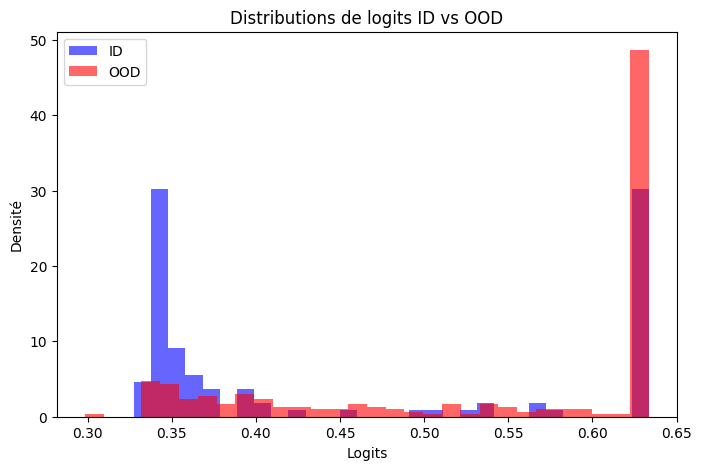

AUC ROC: 0.7031
FPR@TPR95: 0.7103



In [48]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = performance_report(model, test_dataloader,NearOODFramework("near_ood"), correlations=False)